# OCT Fluid Segmentation — CE-Net Variants
Supports three encoders: **ResNet-34** (original CE-Net), **EfficientNet-B4**, **MobileNetV3-Large**.

In [15]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import scipy.io as io
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models          # ← was missing
import timm                                   # ← moved to top

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## 1 · Dataset

In [16]:
class OCTDataset(Dataset):
    def __init__(self, root: str, size: int = 512):
        self.root = root
        self.size = size
        # FIX: use self.root consistently (Subject_10 previously hardcoded input_path)
        self.subject_paths = (
            [os.path.join(self.root, f'Subject_0{i}.mat') for i in range(1, 10)]
            + [os.path.join(self.root, 'Subject_10.mat')]
        )
        self.images: torch.Tensor = torch.tensor([])
        self.masks:  torch.Tensor = torch.tensor([])
        self._load()
        print(f'Images: {self.images.shape}   Masks: {self.masks.shape}')

    # ── dunder ────────────────────────────────────────────────────────────────
    def __len__(self):  return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

    # ── loader ────────────────────────────────────────────────────────────────
    def _load(self):
        for path in tqdm(self.subject_paths, desc='Loading subjects'):
            mat    = io.loadmat(path)
            images = np.expand_dims(
                np.transpose(mat['images'], (2, 0, 1)) / 255.0, 0
            )                                              # (1, C, H, W)
            masks  = np.expand_dims(
                np.nan_to_num(np.transpose(mat['manualFluid1'], (2, 0, 1))), 0
            )                                              # (1, C, H, W)

            images = torch.as_tensor(images, dtype=torch.float32)
            masks  = torch.as_tensor(masks,  dtype=torch.uint8)

            images = F.interpolate(images, size=(self.size, self.size),
                                   mode='bilinear', align_corners=False)
            masks  = F.interpolate(masks.float(), size=(self.size, self.size),
                                   mode='nearest').byte()

            for idx in range(images.shape[1]):
                if masks[0, idx].sum() > 0:
                    # Repeat single-channel image to 3 channels for the encoder
                    img_3ch = images[:, idx].unsqueeze(0).repeat(1, 3, 1, 1)  # (1,3,H,W)
                    self.images = torch.cat([self.images, img_3ch])
                    self.masks  = torch.cat([self.masks,  masks[:, idx].unsqueeze(0)])

In [17]:
# ── Build dataset & split ──────────────────────────────────────────────────────
DATA_ROOT  = '/kaggle/input/chiu-2015/2015_BOE_Chiu'   # ← adjust if needed
IMAGE_SIZE = 512

OCT     = OCTDataset(DATA_ROOT, IMAGE_SIZE)
indices = torch.randperm(len(OCT)).tolist()

OCTrain = torch.utils.data.Subset(OCT, indices[:-20])
OCTest  = torch.utils.data.Subset(OCT, indices[-20:])

print(f'Total: {len(OCT)}  |  Train: {len(OCTrain)}  |  Test: {len(OCTest)}')

Loading subjects: 100%|██████████| 10/10 [00:25<00:00,  2.53s/it]

Images: torch.Size([78, 3, 512, 512])   Masks: torch.Size([78, 1, 512, 512])
Total: 78  |  Train: 58  |  Test: 20


## 2 · Model — CE-Net building blocks

In [18]:
# ── Shared blocks ──────────────────────────────────────────────────────────────
class DACblock(nn.Module):
    def __init__(self, channel):
        super().__init__()
        self.dilate1 = nn.Conv2d(channel, channel, 3, dilation=1, padding=1)
        self.dilate2 = nn.Conv2d(channel, channel, 3, dilation=3, padding=3)
        self.dilate3 = nn.Conv2d(channel, channel, 3, dilation=5, padding=5)
        self.conv1x1 = nn.Conv2d(channel, channel, 1)
        self.relu    = nn.ReLU(inplace=True)

    def forward(self, x):
        d1 = self.relu(self.dilate1(x))
        d2 = self.relu(self.conv1x1(self.dilate2(x)))
        d3 = self.relu(self.conv1x1(self.dilate2(self.dilate1(x))))
        d4 = self.relu(self.conv1x1(self.dilate3(self.dilate2(self.dilate1(x)))))
        return x + d1 + d2 + d3 + d4


class RMPblock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.pool1 = nn.MaxPool2d(2, stride=2)
        self.pool2 = nn.MaxPool2d(3, stride=3)
        self.pool3 = nn.MaxPool2d(5, stride=5)
        self.pool4 = nn.MaxPool2d(6, stride=6)
        self.conv  = nn.Conv2d(in_channels, 1, 1)

    def forward(self, x):
        size = x.shape[2:]
        p1 = F.interpolate(self.conv(self.pool1(x)), size=size, mode='bilinear', align_corners=True)
        p2 = F.interpolate(self.conv(self.pool2(x)), size=size, mode='bilinear', align_corners=True)
        p3 = F.interpolate(self.conv(self.pool3(x)), size=size, mode='bilinear', align_corners=True)
        p4 = F.interpolate(self.conv(self.pool4(x)), size=size, mode='bilinear', align_corners=True)
        return torch.cat([x, p1, p2, p3, p4], dim=1)   # in_channels + 4


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        mid = in_channels // 4
        self.conv1  = nn.Conv2d(in_channels, mid, 1)
        self.bn1    = nn.BatchNorm2d(mid)
        self.deconv = nn.ConvTranspose2d(mid, mid, 3, stride=2, padding=1, output_padding=1)
        self.bn2    = nn.BatchNorm2d(mid)
        self.conv2  = nn.Conv2d(mid, out_channels, 1)
        self.bn3    = nn.BatchNorm2d(out_channels)
        self.relu   = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.deconv(x)))
        x = self.relu(self.bn3(self.conv2(x)))
        return x

In [ ]:
class CENet_SwinT(nn.Module):
    """
    CENet với Swin Transformer-Tiny encoder.

    Swin-T stage channels : e0=96  e1=192  e2=384  e3=768
    Spatial resolution    : e0=H/4  e1=H/8  e2=H/16  e3=H/32

    DecoderBlock tự upsample ×2 bên trong (ConvTranspose2d stride=2)
    nên sau 4 decoder: H/32 → H/16 → H/8 → H/4 → H/2
    Chỉ cần 1× finaldeconv để về H (giống CENet gốc).
    """
    def __init__(self, num_classes=1, img_size=224, pretrained=True):
        super().__init__()

        # ── Encoder ────────────────────────────────────────────────
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            features_only=True,
            img_size=img_size,
            out_indices=(0, 1, 2, 3),
        )
        ec = self.backbone.feature_info.channels()  # [96, 192, 384, 768]

        # ── Context Extractor ──────────────────────────────────────
        self.dac = DACblock(ec[3])        # 768 → 768
        self.rmp = RMPblock(ec[3])        # 768 → 772

        # ── Decoder ────────────────────────────────────────────────
        # Mỗi DecoderBlock tự upsample ×2 bên trong
        # decoder4: 772       → 384,  H/32 → H/16;  cat e2(384) → 768
        # decoder3: 768       → 192,  H/16 → H/8;   cat e1(192) → 384
        # decoder2: 384       → 96,   H/8  → H/4;   cat e0(96)  → 192
        # decoder1: 192       → 96,   H/4  → H/2    (không skip)
        self.decoder4 = DecoderBlock(ec[3] + 4, ec[2])   # 772 → 384
        self.decoder3 = DecoderBlock(ec[2] * 2, ec[1])   # 768 → 192
        self.decoder2 = DecoderBlock(ec[1] * 2, ec[0])   # 384 → 96
        self.decoder1 = DecoderBlock(ec[0] * 2, ec[0])   # 192 → 96

        # ── Final head ─────────────────────────────────────────────
        # d1 ra H/2 → 1× ConvTranspose2d → H (giống CENet gốc)
        self.finaldeconv1 = nn.ConvTranspose2d(ec[0], 32, 4, stride=2, padding=1)
        self.finalconv2   = nn.Conv2d(32, 32, 3, padding=1)
        self.finalconv3   = nn.Conv2d(32, num_classes, 1)
        self.relu         = nn.ReLU(inplace=True)

    @staticmethod
    def _bchw(feats):
        """Swin trả về (B,H,W,C) → (B,C,H,W)."""
        return [f.permute(0, 3, 1, 2).contiguous() for f in feats]

    def forward(self, x):
        # ── Encoder ────────────────────────────────────────────────
        e0, e1, e2, e3 = self._bchw(self.backbone(x))
        # e0: B×96 ×H/4 ×W/4
        # e1: B×192×H/8 ×W/8
        # e2: B×384×H/16×W/16
        # e3: B×768×H/32×W/32

        # ── Context Extractor ──────────────────────────────────────
        dac_out = self.dac(e3)
        rmp_out = self.rmp(dac_out)   # B×772×H/32×W/32

        # ── Decoder + skip ─────────────────────────────────────────
        d4     = self.decoder4(rmp_out)            # B×384×H/16
        d4_cat = torch.cat([d4, e2], dim=1)        # B×768×H/16

        d3     = self.decoder3(d4_cat)             # B×192×H/8
        d3_cat = torch.cat([d3, e1], dim=1)        # B×384×H/8

        d2     = self.decoder2(d3_cat)             # B×96×H/4
        d2_cat = torch.cat([d2, e0], dim=1)        # B×192×H/4

        d1     = self.decoder1(d2_cat)             # B×96×H/2

        # ── Final head ─────────────────────────────────────────────
        out = self.relu(self.finaldeconv1(d1))     # B×32×H
        out = self.relu(self.finalconv2(out))      # B×32×H
        return self.finalconv3(out)                # B×num_classes×H×W


In [19]:
# ── Variant 1 : Original CE-Net (ResNet-34 encoder) ───────────────────────────
class CENet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        self.firstconv   = resnet.conv1
        self.firstbn     = resnet.bn1
        self.firstrelu   = resnet.relu
        self.firstmaxpool = resnet.maxpool

        self.encoder1 = resnet.layer1   # 64ch
        self.encoder2 = resnet.layer2   # 128ch
        self.encoder3 = resnet.layer3   # 256ch
        self.encoder4 = resnet.layer4   # 512ch

        self.dac = DACblock(512)
        self.rmp = RMPblock(512)        # → 516ch

        self.decoder4 = DecoderBlock(516, 256)
        self.decoder3 = DecoderBlock(512, 128)   # 256 + e3(256)
        self.decoder2 = DecoderBlock(256, 64)    # 128 + e2(128)
        self.decoder1 = DecoderBlock(128, 64)    #  64 + e1(64)

        self.finaldeconv1 = nn.ConvTranspose2d(128, 32, 4, stride=2, padding=1)  # 64+64
        self.finalconv2   = nn.Conv2d(32, 32, 3, padding=1)
        self.finalconv3   = nn.Conv2d(32, num_classes, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        e0 = self.firstrelu(self.firstbn(self.firstconv(x)))   # /2,  64ch
        x  = self.firstmaxpool(e0)                             # /4
        e1 = self.encoder1(x)                                  # /4,  64ch
        e2 = self.encoder2(e1)                                 # /8,  128ch
        e3 = self.encoder3(e2)                                 # /16, 256ch
        e4 = self.encoder4(e3)                                 # /32, 512ch

        rmp_out = self.rmp(self.dac(e4))                       # 516ch

        d4 = self.decoder4(rmp_out)                            # 256ch, /16
        d3 = self.decoder3(torch.cat([d4, e3], 1))            # 128ch, /8
        d2 = self.decoder2(torch.cat([d3, e2], 1))            #  64ch, /4
        d1 = self.decoder1(torch.cat([d2, e1], 1))            #  64ch, /2

        out = self.relu(self.finaldeconv1(torch.cat([d1, e0], 1)))  # ×2 → full res
        out = self.relu(self.finalconv2(out))
        out = self.finalconv3(out)
        return out

In [20]:
# ── Variant 2 : CE-Net with EfficientNet-B4 encoder ───────────────────────────
class CENet_EffB4(nn.Module):
    """
    Encoder channels (512px input):
      e0: (B,  24, 256, 256)   e1: (B,  32, 128, 128)
      e2: (B,  56,  64,  64)   e3: (B, 160,  32,  32)
      e4: (B, 448,  16,  16)
    """
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4', pretrained=pretrained,
            features_only=True, out_indices=(0, 1, 2, 3, 4),
        )
        self.dac = DACblock(448)
        self.rmp = RMPblock(448)            # → 452ch

        self.decoder4 = DecoderBlock(452,  160)
        self.decoder3 = DecoderBlock(320,   56)   # 160 + e3(160)
        self.decoder2 = DecoderBlock(112,   32)   #  56 + e2( 56)
        self.decoder1 = DecoderBlock( 64,   24)   #  32 + e1( 32)

        self.finaldeconv1 = nn.ConvTranspose2d(48, 32, 4, stride=2, padding=1)  # 24+24
        self.finalconv2   = nn.Conv2d(32, 32, 3, padding=1)
        self.finalconv3   = nn.Conv2d(32, num_classes, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        e0, e1, e2, e3, e4 = self.backbone(x)

        rmp_out = self.rmp(self.dac(e4))

        d4 = self.decoder4(rmp_out)
        d3 = self.decoder3(torch.cat([d4, e3], 1))
        d2 = self.decoder2(torch.cat([d3, e2], 1))
        d1 = self.decoder1(torch.cat([d2, e1], 1))

        out = self.relu(self.finaldeconv1(torch.cat([d1, e0], 1)))
        out = self.relu(self.finalconv2(out))
        out = self.finalconv3(out)
        return out

In [21]:
# ── Variant 3 : CE-Net with MobileNetV3-Large encoder ─────────────────────────
class CENet_MobileV3(nn.Module):
    """
    Encoder channels (512px input):
      e0: (B,  16, 256, 256)   e1: (B,  24, 128, 128)
      e2: (B,  40,  64,  64)   e3: (B, 112,  32,  32)
      e4: (B, 960,  16,  16)
    """
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'mobilenetv3_large_100', pretrained=pretrained,
            features_only=True, out_indices=(0, 1, 2, 3, 4),
        )
        # Project 960 → 448 before DAC to keep compute reasonable
        self.bottleneck = nn.Sequential(
            nn.Conv2d(960, 448, 1),
            nn.BatchNorm2d(448),
            nn.ReLU(inplace=True),
        )
        self.dac = DACblock(448)
        self.rmp = RMPblock(448)             # → 452ch

        self.decoder4 = DecoderBlock(452, 112)
        self.decoder3 = DecoderBlock(224,  40)   # 112 + e3(112)
        self.decoder2 = DecoderBlock( 80,  24)   #  40 + e2( 40)
        self.decoder1 = DecoderBlock( 48,  16)   #  24 + e1( 24)

        self.finaldeconv1 = nn.ConvTranspose2d(32, 32, 4, stride=2, padding=1)  # 16+16
        self.finalconv2   = nn.Conv2d(32, 32, 3, padding=1)
        self.finalconv3   = nn.Conv2d(32, num_classes, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        e0, e1, e2, e3, e4 = self.backbone(x)

        e4      = self.bottleneck(e4)
        rmp_out = self.rmp(self.dac(e4))

        d4 = self.decoder4(rmp_out)
        d3 = self.decoder3(torch.cat([d4, e3], 1))
        d2 = self.decoder2(torch.cat([d3, e2], 1))
        d1 = self.decoder1(torch.cat([d2, e1], 1))

        out = self.relu(self.finaldeconv1(torch.cat([d1, e0], 1)))
        out = self.relu(self.finalconv2(out))
        out = self.finalconv3(out)
        return out

## 3 · Metrics

In [22]:
def dice_score(pred_logits: torch.Tensor, targets: torch.Tensor,
               threshold: float = 0.5, smooth: float = 1e-6) -> float:
    """Binary Dice coefficient averaged over the batch."""
    preds = (torch.sigmoid(pred_logits) > threshold).float()
    tgts  = targets.float()
    inter = (preds * tgts).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + tgts.sum(dim=(1, 2, 3))
    return ((2 * inter + smooth) / (union + smooth)).mean().item()


def iou_score(pred_logits: torch.Tensor, targets: torch.Tensor,
              threshold: float = 0.5, smooth: float = 1e-6) -> float:
    """Binary IoU averaged over the batch."""
    preds = (torch.sigmoid(pred_logits) > threshold).float()
    tgts  = targets.float()
    inter = (preds * tgts).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + tgts.sum(dim=(1, 2, 3)) - inter
    iou   = (inter + smooth) / (union + smooth)
    return iou.clamp(0.0, 1.0).mean().item()

## 4 · Training & Validation

## CENet

In [23]:
import torch.nn as nn
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight

    def forward(self, outputs, targets):
        bce_loss = self.bce(outputs, targets)
        # Dice trên sigmoid output
        probs = torch.sigmoid(outputs)
        smooth = 1e-6
        inter = (probs * targets).sum(dim=(1, 2, 3))
        dice_loss = 1 - (2 * inter + smooth) / (probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + smooth)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss.mean()

In [33]:
# ── Choose the model variant here ─────────────────────────────────────────────
# model = CENet(num_classes=1).to(device)           # ResNet-34
model = CENet(num_classes=1).to(device)     
# model = CENet_MobileV3(num_classes=1).to(device)  # MobileNetV3-Large

criterion = BCEDiceLoss(bce_weight=0.5)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 50
BATCH_SIZE = 4

train_loader = DataLoader(OCTrain, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(OCTest,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# History for plotting
history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': [], 'val_mse': []}

print(f'Model: {model.__class__.__name__}   |   '
      f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Model: CENet   |   Params: 29,257,205


In [34]:
# ── Khởi tạo trước vòng lặp ───────────────────────────────────────────────────
best_dice    = 0.0
best_epoch   = 0
best_metrics = {}
MODEL_SAVE_PATH = f'{model.__class__.__name__}_best.pth'

for epoch in range(1, num_epochs + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} [train]', leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks.float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_dice, val_iou, val_mse = 0.0, 0.0, 0.0, 0.0
    n_batches = 0
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f'Epoch {epoch}/{num_epochs} [val]  ', leave=False):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks.float()).item()
            val_dice += dice_score(outputs, masks)
            val_iou  += iou_score(outputs, masks)
            val_mse  += F.mse_loss(torch.sigmoid(outputs), masks.float()).item()
            n_batches += 1
    val_loss /= n_batches
    val_dice /= n_batches
    val_iou  /= n_batches
    val_mse  /= n_batches

    # ── Log ────────────────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    history['val_mse'].append(val_mse)

    # ── Lưu model tốt nhất ────────────────────────────────────────────────────
    if val_dice > best_dice:
        best_dice  = val_dice
        best_epoch = epoch
        best_metrics = {
            'epoch'     : epoch,
            'train_loss': train_loss,
            'val_loss'  : val_loss,
            'val_dice'  : val_dice,
            'val_iou'   : val_iou,
            'val_mse'   : val_mse,
        }
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics'             : best_metrics,
        }, MODEL_SAVE_PATH)
        print(f'Epoch {epoch:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Dice: {val_dice:.4f} | '
              f'IoU: {val_iou:.4f} | '
              f'MSE: {val_mse:.4f}  ✅ saved')
    else:
        print(f'Epoch {epoch:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Dice: {val_dice:.4f} | '
              f'IoU: {val_iou:.4f} | '
              f'MSE: {val_mse:.4f}')

# ── Tổng kết sau training ──────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'Best model at Epoch {best_epoch}:')
for k, v in best_metrics.items():
    print(f'  {k:<12}: {v:.4f}' if isinstance(v, float) else f'  {k:<12}: {v}')
print(f'Saved to: {MODEL_SAVE_PATH}')


Epoch 1/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  6.75it/s]
                                                                   
Epoch 1/50 [val]  : 100%|██████████| 5/5 [00:00<00:00, 14.02it/s]
                                                                 

Epoch   1/50 | Train Loss: 0.7518 | Val Loss: 0.7689 | Dice: 0.0000 | IoU: 0.0000 | MSE: 0.2750  ✅ saved



Epoch 2/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  6.77it/s]
                                                                   
Epoch 2/50 [val]  : 100%|██████████| 5/5 [00:00<00:00, 13.93it/s]
                                                                 

Epoch   2/50 | Train Loss: 0.6898 | Val Loss: 0.7024 | Dice: 0.0000 | IoU: 0.0000 | MSE: 0.2117



Epoch 3/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  6.75it/s]
                                                                   
Epoch 3/50 [val]  : 100%|██████████| 5/5 [00:00<00:00, 14.58it/s]
                                                                 

...

Epoch  48/50 | Train Loss: -59.8317 | Val Loss: -6.5903 | Dice: 0.7658 | IoU: 0.6200 | MSE: 0.0794



Epoch 49/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  6.90it/s]
                                                                    
Epoch 49/50 [val]  : 100%|██████████| 5/5 [00:00<00:00, 14.28it/s]
                                                                  

Epoch  49/50 | Train Loss: -62.4451 | Val Loss: -7.3019 | Dice: 0.7782 | IoU: 0.6322 | MSE: 0.0795



Epoch 50/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  6.89it/s]
                                                                    
Epoch 50/50 [val]  : 100%|██████████| 5/5 [00:00<00:00, 14.76it/s]
                                                                  

Epoch  50/50 | Train Loss: -70.6506 | Val Loss: -7.0851 | Dice: 0.7869 | IoU: 0.6335 | MSE: 0.0796

Best model at Epoch 23:
  epoch       : 23
  train_loss  : -1.4312
  val_loss    : -0.1577
  val_dice    : 0.8169
  val_iou     : 0.6717
  val_mse     : 0.0792
Saved to: CENet_best.pth


## 5 · Training curves

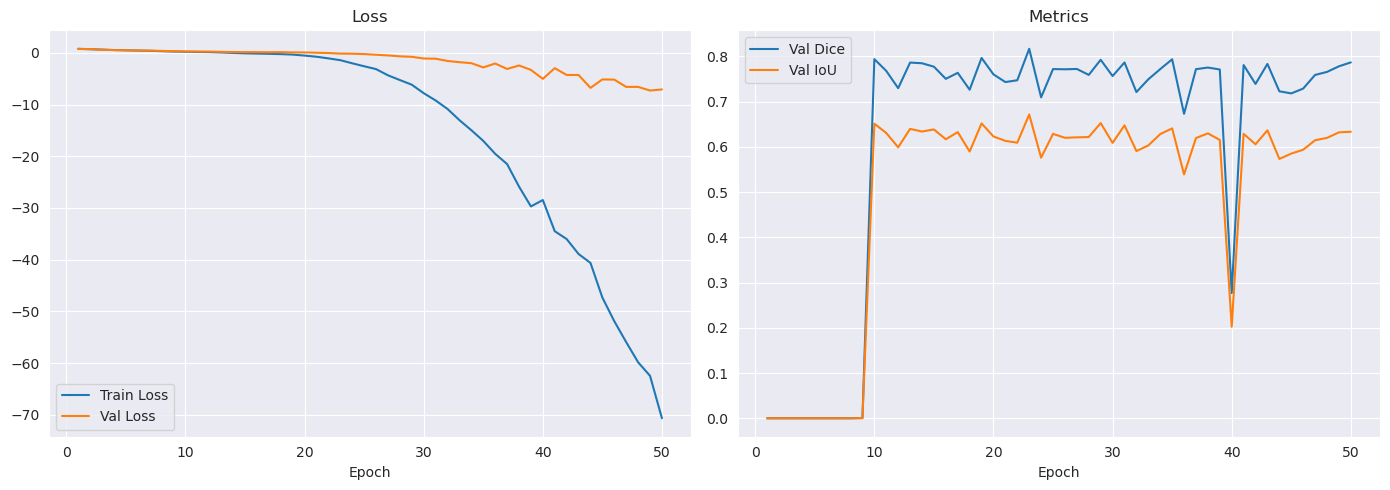

In [35]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['val_dice'], label='Val Dice')
axes[1].plot(epochs, history['val_iou'],  label='Val IoU')
axes[1].set_title('Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 6 · Qualitative visualisation

In [36]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Metrics: {checkpoint['metrics']}")

Loaded best model from epoch 23
Metrics: {'epoch': 23, 'train_loss': -1.4312017326553663, 'val_loss': -0.157742727547884, 'val_dice': 0.816939651966095, 'val_iou': 0.6716716289520264, 'val_mse': 0.07920508980751037}


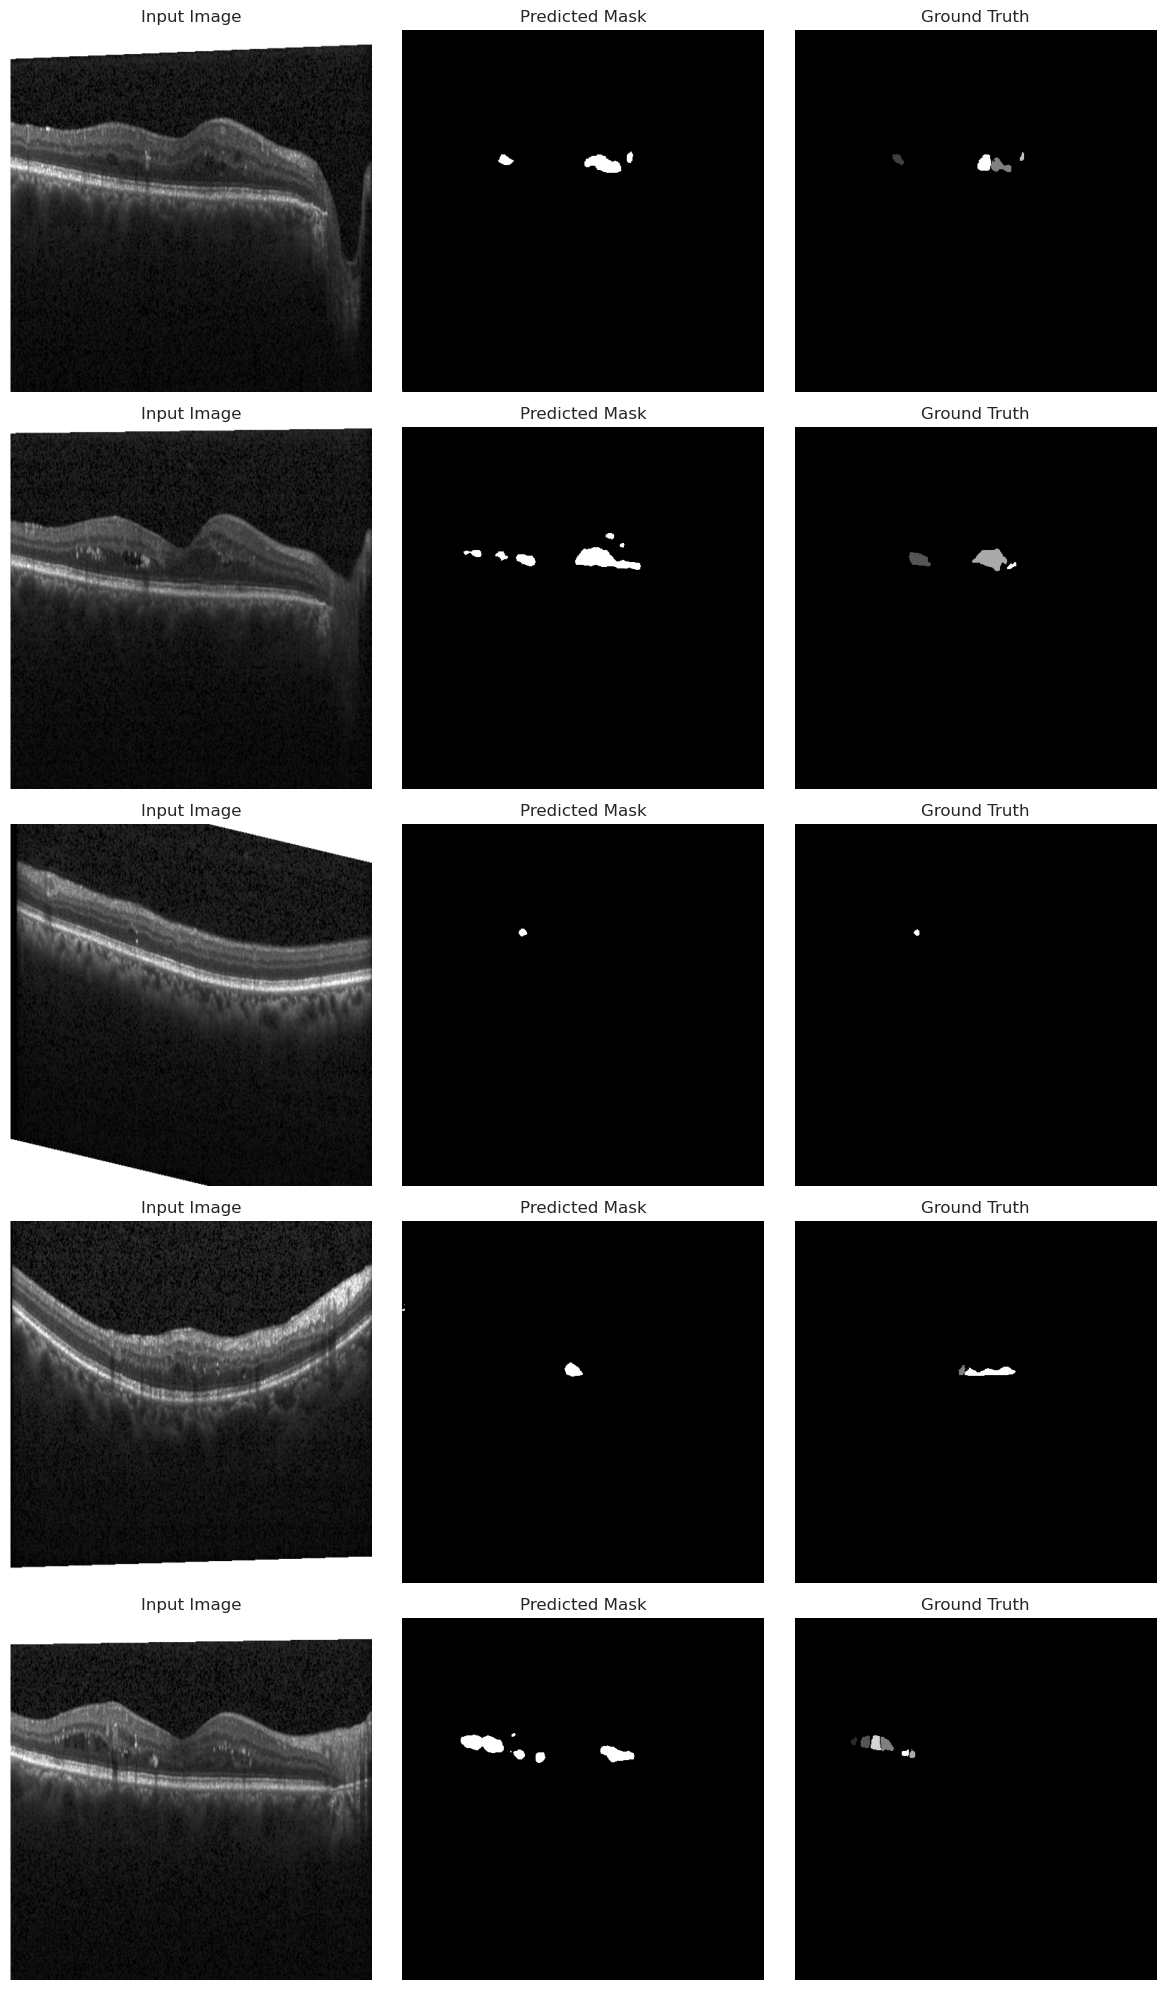

In [37]:
def plot_examples(loader, num_examples: int = 5):
    model.eval()
    fig, axes = plt.subplots(num_examples, 3, figsize=(12, num_examples * 4))
    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = (torch.sigmoid(model(images)) > 0.5)
            for b in range(images.shape[0]):
                if shown >= num_examples:
                    break
                img_np  = images[b].cpu().permute(1, 2, 0).numpy()
                # Normalise to [0,1] for display
                img_np  = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
                axes[shown][0].imshow(img_np)
                axes[shown][0].set_title('Input Image')
                axes[shown][1].imshow(preds[b, 0].cpu(), cmap='gray')
                axes[shown][1].set_title('Predicted Mask')
                axes[shown][2].imshow(masks[b, 0].cpu(), cmap='gray')
                axes[shown][2].set_title('Ground Truth')
                for ax in axes[shown]:
                    ax.axis('off')
                shown += 1
            if shown >= num_examples:
                break
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150)
    plt.show()

plot_examples(test_loader, num_examples=5)

## CENET + EfficentNet B4

In [ ]:
# ── Khởi tạo trước vòng lặp ───────────────────────────────────────────────────
best_dice    = 0.0
best_epoch   = 0
best_metrics = {}
MODEL_SAVE_PATH = f'{model.__class__.__name__}_best.pth'

for epoch in range(1, num_epochs + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} [train]', leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks.float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_dice, val_iou, val_mse = 0.0, 0.0, 0.0, 0.0
    n_batches = 0
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f'Epoch {epoch}/{num_epochs} [val]  ', leave=False):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks.float()).item()
            val_dice += dice_score(outputs, masks)
            val_iou  += iou_score(outputs, masks)
            val_mse  += F.mse_loss(torch.sigmoid(outputs), masks.float()).item()
            n_batches += 1
    val_loss /= n_batches
    val_dice /= n_batches
    val_iou  /= n_batches
    val_mse  /= n_batches

    # ── Log ────────────────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    history['val_mse'].append(val_mse)

    # ── Lưu model tốt nhất ────────────────────────────────────────────────────
    if val_dice > best_dice:
        best_dice  = val_dice
        best_epoch = epoch
        best_metrics = {
            'epoch'     : epoch,
            'train_loss': train_loss,
            'val_loss'  : val_loss,
            'val_dice'  : val_dice,
            'val_iou'   : val_iou,
            'val_mse'   : val_mse,
        }
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics'             : best_metrics,
        }, MODEL_SAVE_PATH)
        print(f'Epoch {epoch:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Dice: {val_dice:.4f} | '
              f'IoU: {val_iou:.4f} | '
              f'MSE: {val_mse:.4f}  ✅ saved')
    else:
        print(f'Epoch {epoch:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Dice: {val_dice:.4f} | '
              f'IoU: {val_iou:.4f} | '
              f'MSE: {val_mse:.4f}')

# ── Tổng kết sau training ──────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'Best model at Epoch {best_epoch}:')
for k, v in best_metrics.items():
    print(f'  {k:<12}: {v:.4f}' if isinstance(v, float) else f'  {k:<12}: {v}')
print(f'Saved to: {MODEL_SAVE_PATH}')


Epoch 1/50 [train]: 100%|██████████| 15/15 [00:05<00:00,  3.11it/s]
                                                                   
Epoch 1/50 [val]  : 100%|██████████| 5/5 [00:00<00:00,  9.31it/s]
                                                                 

Epoch   1/50 | Train Loss: 0.8159 | Val Loss: 0.7285 | Dice: 0.0046 | IoU: 0.0023 | MSE: 0.2363  ✅ saved



Epoch 2/50 [train]: 100%|██████████| 15/15 [00:04<00:00,  3.40it/s]
                                                                   
Epoch 2/50 [val]  : 100%|██████████| 5/5 [00:00<00:00,  9.41it/s]
                                                                 

Epoch   2/50 | Train Loss: 0.6468 | Val Loss: 0.6256 | Dice: 0.0000 | IoU: 0.0000 | MSE: 0.1493



Epoch 3/50 [train]: 100%|██████████| 15/15 [00:04<00:00,  3.31it/s]
                                                                   
Epoch 3/50 [val]  : 100%|██████████| 5/5 [00:00<00:00,  9.12it/s]
                                                                 

...

Epoch  48/50 | Train Loss: -15.5382 | Val Loss: -1.9367 | Dice: 0.6591 | IoU: 0.5111 | MSE: 0.0821



Epoch 49/50 [train]: 100%|██████████| 15/15 [00:04<00:00,  3.44it/s]
                                                                    
Epoch 49/50 [val]  : 100%|██████████| 5/5 [00:00<00:00,  9.56it/s]
                                                                  

Epoch  49/50 | Train Loss: -18.2345 | Val Loss: -2.0770 | Dice: 0.6472 | IoU: 0.4972 | MSE: 0.0831



Epoch 50/50 [train]: 100%|██████████| 15/15 [00:04<00:00,  3.41it/s]
                                                                    
Epoch 50/50 [val]  : 100%|██████████| 5/5 [00:00<00:00,  9.35it/s]
                                                                  

Epoch  50/50 | Train Loss: -19.7055 | Val Loss: -2.4403 | Dice: 0.6131 | IoU: 0.4644 | MSE: 0.0845

Best model at Epoch 33:
  epoch       : 33
  train_loss  : -1.7127
  val_loss    : -0.0798
  val_dice    : 0.7119
  val_iou     : 0.5764
  val_mse     : 0.0812
Saved to: CENet_EffB4_best.pth


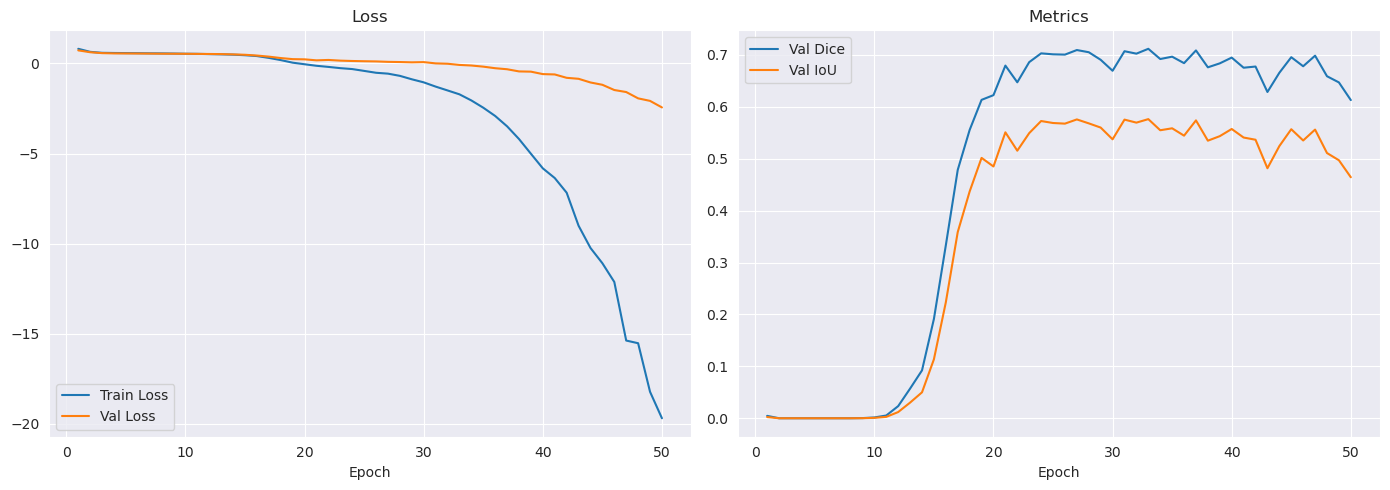

In [ ]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['val_dice'], label='Val Dice')
axes[1].plot(epochs, history['val_iou'],  label='Val IoU')
axes[1].set_title('Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

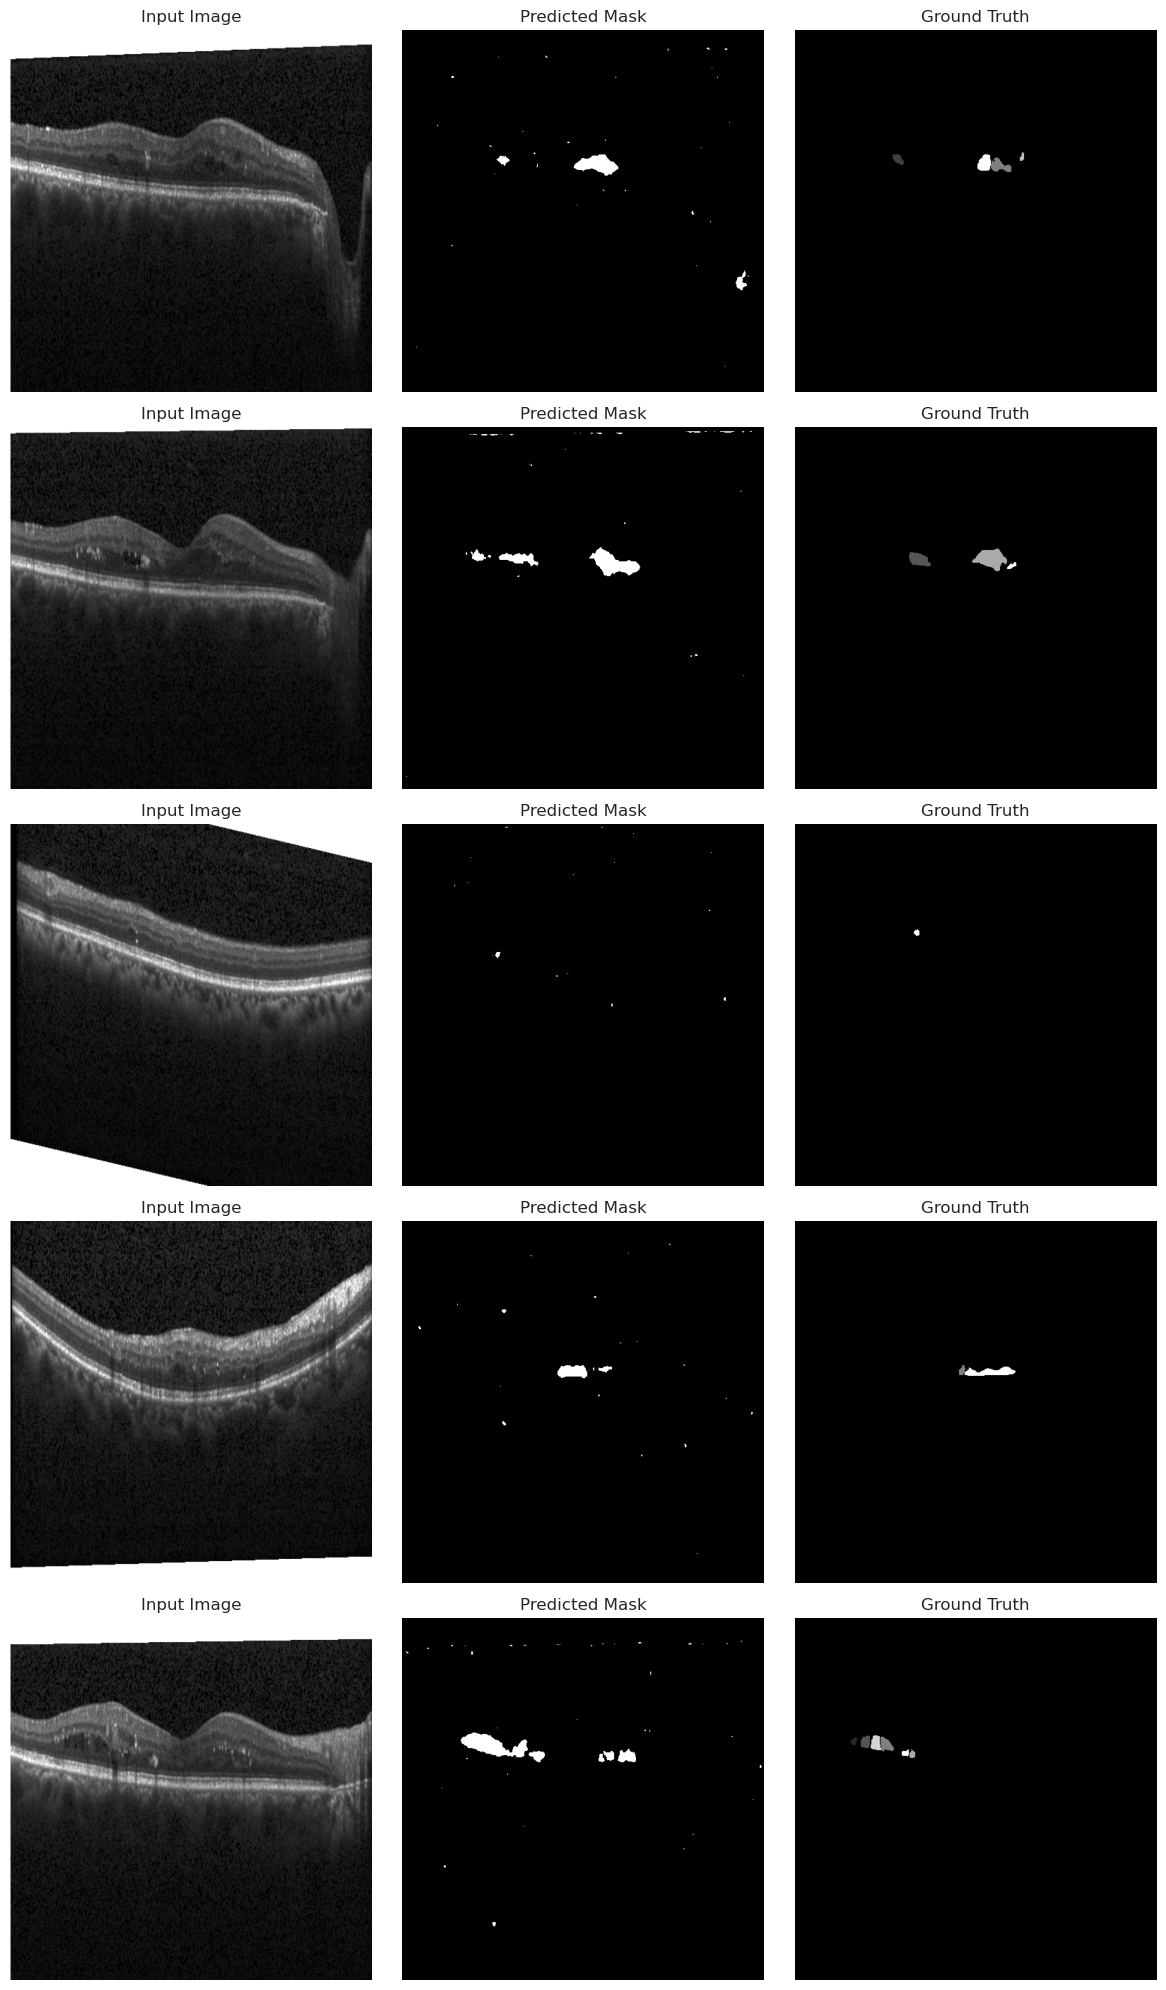

In [ ]:
def plot_examples(loader, num_examples: int = 5):
    model.eval()
    fig, axes = plt.subplots(num_examples, 3, figsize=(12, num_examples * 4))
    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = (torch.sigmoid(model(images)) > 0.5)
            for b in range(images.shape[0]):
                if shown >= num_examples:
                    break
                img_np  = images[b].cpu().permute(1, 2, 0).numpy()
                # Normalise to [0,1] for display
                img_np  = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
                axes[shown][0].imshow(img_np)
                axes[shown][0].set_title('Input Image')
                axes[shown][1].imshow(preds[b, 0].cpu(), cmap='gray')
                axes[shown][1].set_title('Predicted Mask')
                axes[shown][2].imshow(masks[b, 0].cpu(), cmap='gray')
                axes[shown][2].set_title('Ground Truth')
                for ax in axes[shown]:
                    ax.axis('off')
                shown += 1
            if shown >= num_examples:
                break
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150)
    plt.show()

plot_examples(test_loader, num_examples=5)

## CENet + MobileNetV3

In [ ]:
# ── Khởi tạo trước vòng lặp ───────────────────────────────────────────────────
best_dice    = 0.0
best_epoch   = 0
best_metrics = {}
MODEL_SAVE_PATH = f'{model.__class__.__name__}_best.pth'

for epoch in range(1, num_epochs + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} [train]', leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks.float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_dice, val_iou, val_mse = 0.0, 0.0, 0.0, 0.0
    n_batches = 0
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f'Epoch {epoch}/{num_epochs} [val]  ', leave=False):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks.float()).item()
            val_dice += dice_score(outputs, masks)
            val_iou  += iou_score(outputs, masks)
            val_mse  += F.mse_loss(torch.sigmoid(outputs), masks.float()).item()
            n_batches += 1
    val_loss /= n_batches
    val_dice /= n_batches
    val_iou  /= n_batches
    val_mse  /= n_batches

    # ── Log ────────────────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    history['val_mse'].append(val_mse)

    # ── Lưu model tốt nhất ────────────────────────────────────────────────────
    if val_dice > best_dice:
        best_dice  = val_dice
        best_epoch = epoch
        best_metrics = {
            'epoch'     : epoch,
            'train_loss': train_loss,
            'val_loss'  : val_loss,
            'val_dice'  : val_dice,
            'val_iou'   : val_iou,
            'val_mse'   : val_mse,
        }
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics'             : best_metrics,
        }, MODEL_SAVE_PATH)
        print(f'Epoch {epoch:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Dice: {val_dice:.4f} | '
              f'IoU: {val_iou:.4f} | '
              f'MSE: {val_mse:.4f}  ✅ saved')
    else:
        print(f'Epoch {epoch:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Dice: {val_dice:.4f} | '
              f'IoU: {val_iou:.4f} | '
              f'MSE: {val_mse:.4f}')

# ── Tổng kết sau training ──────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'Best model at Epoch {best_epoch}:')
for k, v in best_metrics.items():
    print(f'  {k:<12}: {v:.4f}' if isinstance(v, float) else f'  {k:<12}: {v}')
print(f'Saved to: {MODEL_SAVE_PATH}')


Epoch 1/50 [train]:  93%|█████████▎| 14/15 [00:02<00:00,  6.21it/s]
                                                                   
Epoch 1/50 [val]  :  80%|████████  | 4/5 [00:00<00:00, 14.84it/s]
                                                                 

Epoch   1/50 | Train Loss: 0.7863 | Val Loss: 0.7676 | Dice: 0.0006 | IoU: 0.0003 | MSE: 0.2740  ✅ saved



Epoch 2/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  7.86it/s]
                                                                   
Epoch 2/50 [val]  :  80%|████████  | 4/5 [00:00<00:00, 15.28it/s]
                                                                 

Epoch   2/50 | Train Loss: 0.6976 | Val Loss: 0.6670 | Dice: 0.0000 | IoU: 0.0000 | MSE: 0.1815



Epoch 3/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  7.88it/s]
                                                                   
Epoch 3/50 [val]  :  80%|████████  | 4/5 [00:00<00:00, 15.02it/s]
                                                                 

...

Epoch  48/50 | Train Loss: -4.6333 | Val Loss: -0.3780 | Dice: 0.7015 | IoU: 0.5709 | MSE: 0.0827



Epoch 49/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  7.97it/s]
                                                                    
Epoch 49/50 [val]  :  80%|████████  | 4/5 [00:00<00:00, 14.87it/s]
                                                                  

Epoch  49/50 | Train Loss: -5.1570 | Val Loss: -0.2668 | Dice: 0.6169 | IoU: 0.5021 | MSE: 0.0846



Epoch 50/50 [train]: 100%|██████████| 15/15 [00:02<00:00,  7.74it/s]
                                                                    
Epoch 50/50 [val]  :  80%|████████  | 4/5 [00:00<00:00, 14.63it/s]
                                                                  

Epoch  50/50 | Train Loss: -5.5554 | Val Loss: -0.1897 | Dice: 0.4706 | IoU: 0.3805 | MSE: 0.0857

Best model at Epoch 29:
  epoch       : 29
  train_loss  : -0.2974
  val_loss    : 0.1134
  val_dice    : 0.7531
  val_iou     : 0.6162
  val_mse     : 0.0814
Saved to: CENet_MobileV3_best.pth


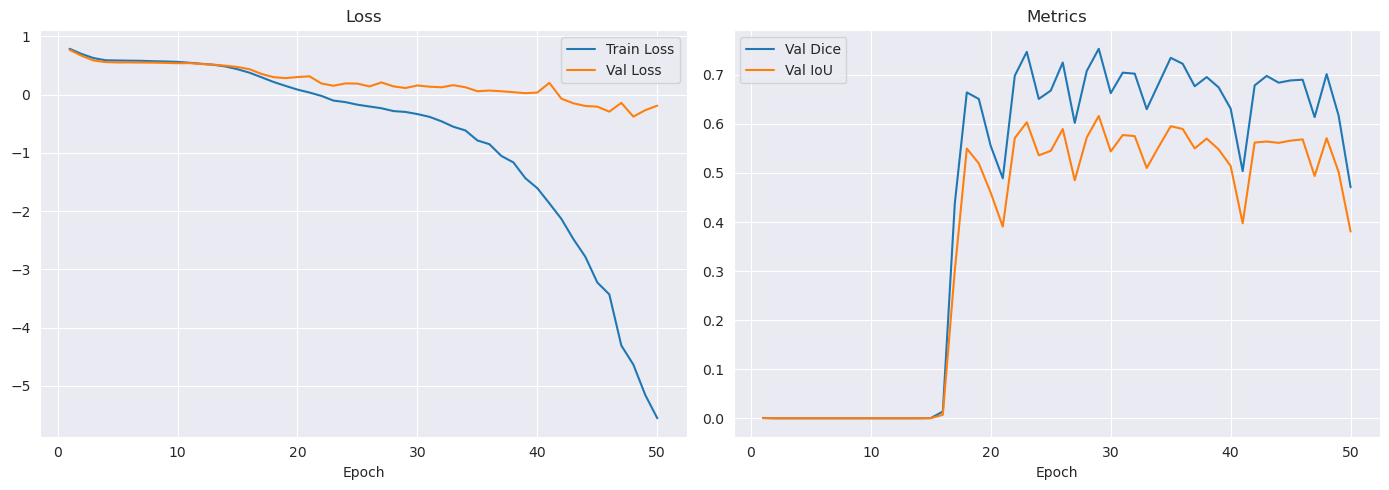

In [ ]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['val_dice'], label='Val Dice')
axes[1].plot(epochs, history['val_iou'],  label='Val IoU')
axes[1].set_title('Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

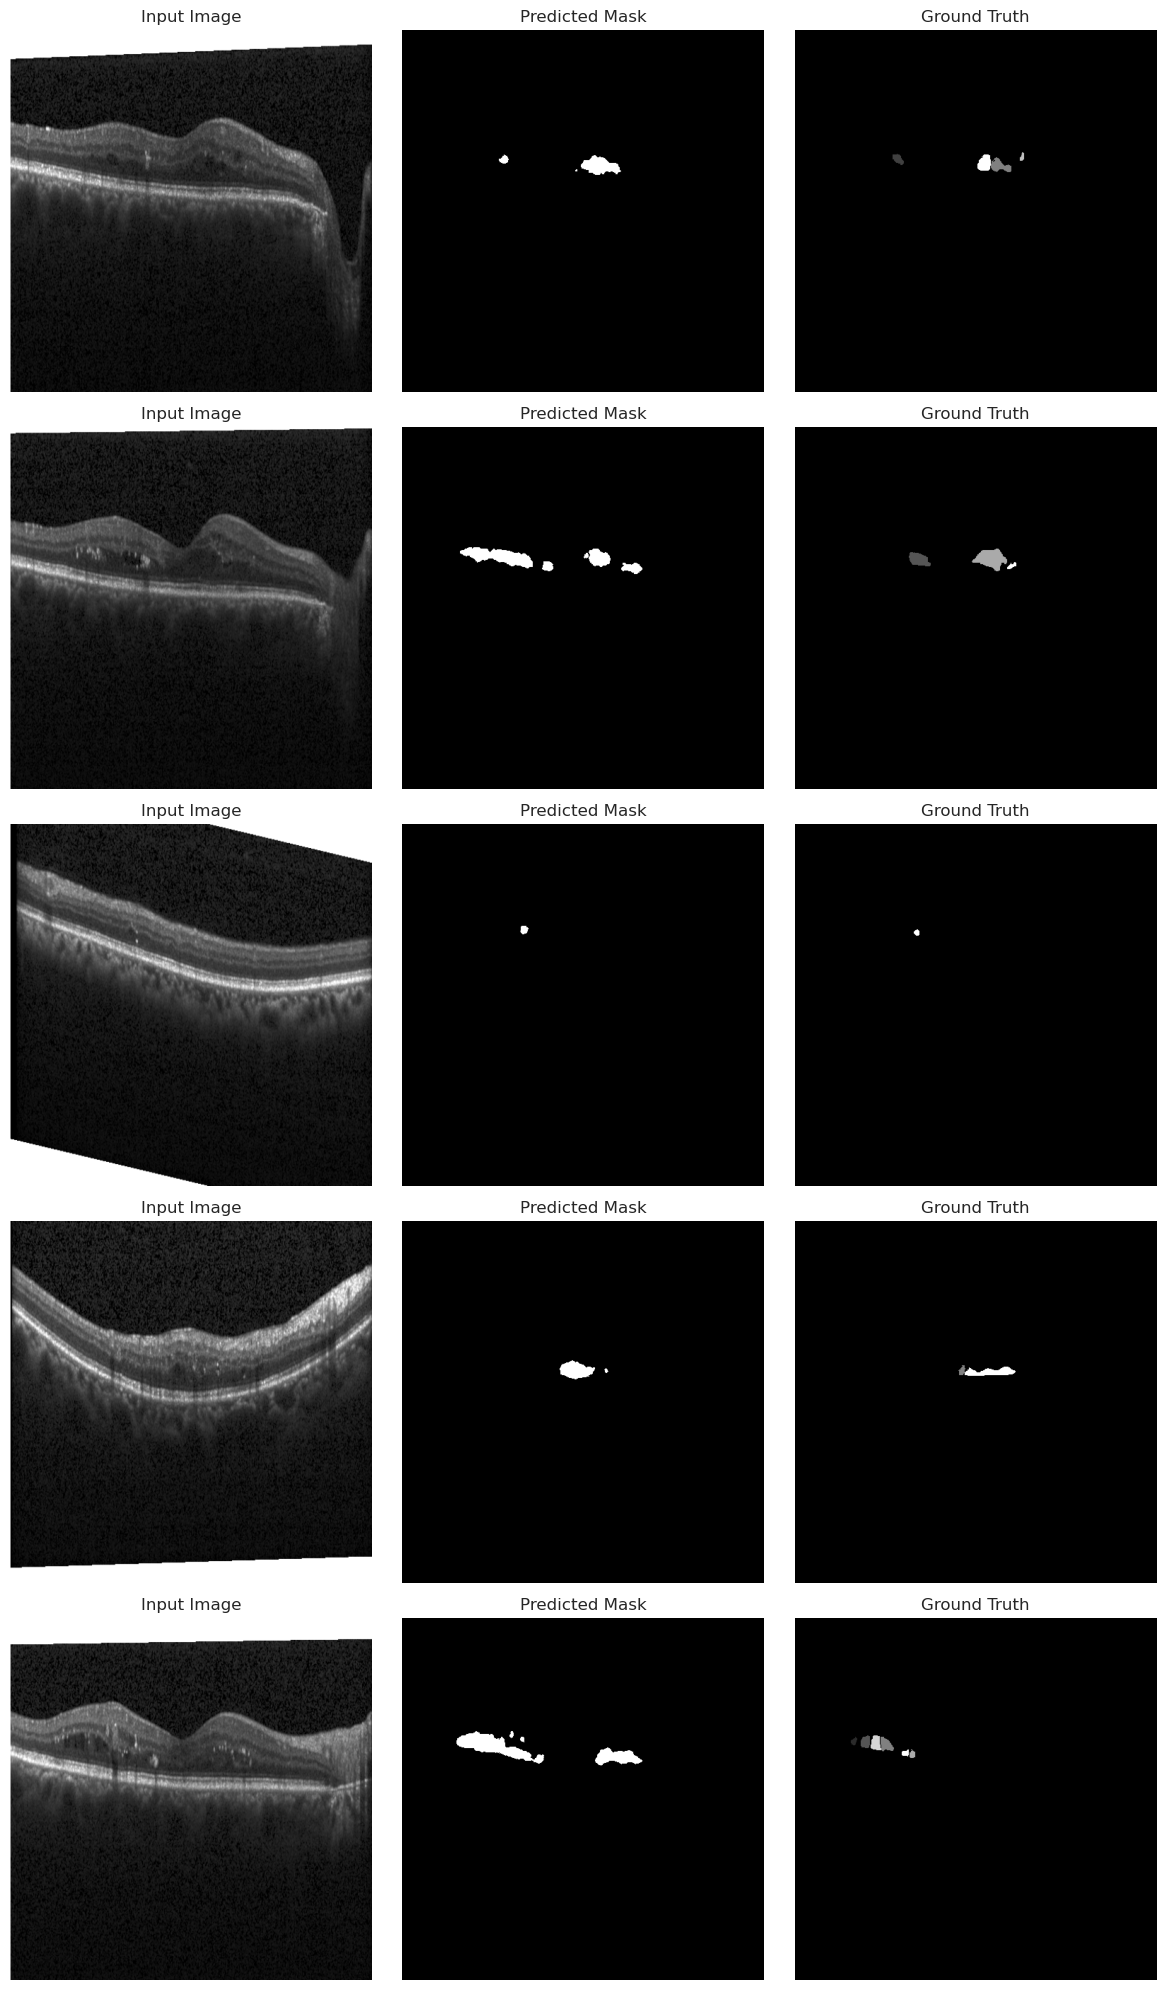

In [ ]:
def plot_examples(loader, num_examples: int = 5):
    model.eval()
    fig, axes = plt.subplots(num_examples, 3, figsize=(12, num_examples * 4))
    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = (torch.sigmoid(model(images)) > 0.5)
            for b in range(images.shape[0]):
                if shown >= num_examples:
                    break
                img_np  = images[b].cpu().permute(1, 2, 0).numpy()
                # Normalise to [0,1] for display
                img_np  = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
                axes[shown][0].imshow(img_np)
                axes[shown][0].set_title('Input Image')
                axes[shown][1].imshow(preds[b, 0].cpu(), cmap='gray')
                axes[shown][1].set_title('Predicted Mask')
                axes[shown][2].imshow(masks[b, 0].cpu(), cmap='gray')
                axes[shown][2].set_title('Ground Truth')
                for ax in axes[shown]:
                    ax.axis('off')
                shown += 1
            if shown >= num_examples:
                break
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150)
    plt.show()

plot_examples(test_loader, num_examples=5)

## CENet + SwinT

In [ ]:
# ── Khởi tạo trước vòng lặp ───────────────────────────────────────────────────
best_dice    = 0.0
best_epoch   = 0
best_metrics = {}
MODEL_SAVE_PATH = f'{model.__class__.__name__}_best.pth'

for epoch in range(1, num_epochs + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} [train]', leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks.float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_dice, val_iou, val_mse = 0.0, 0.0, 0.0, 0.0
    n_batches = 0
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f'Epoch {epoch}/{num_epochs} [val]  ', leave=False):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks.float()).item()
            val_dice += dice_score(outputs, masks)
            val_iou  += iou_score(outputs, masks)
            val_mse  += F.mse_loss(torch.sigmoid(outputs), masks.float()).item()
            n_batches += 1
    val_loss /= n_batches
    val_dice /= n_batches
    val_iou  /= n_batches
    val_mse  /= n_batches

    # ── Log ────────────────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    history['val_mse'].append(val_mse)

    # ── Lưu model tốt nhất ────────────────────────────────────────────────────
    if val_dice > best_dice:
        best_dice  = val_dice
        best_epoch = epoch
        best_metrics = {
            'epoch'     : epoch,
            'train_loss': train_loss,
            'val_loss'  : val_loss,
            'val_dice'  : val_dice,
            'val_iou'   : val_iou,
            'val_mse'   : val_mse,
        }
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics'             : best_metrics,
        }, MODEL_SAVE_PATH)
        print(f'Epoch {epoch:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Dice: {val_dice:.4f} | '
              f'IoU: {val_iou:.4f} | '
              f'MSE: {val_mse:.4f}  ✅ saved')
    else:
        print(f'Epoch {epoch:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Dice: {val_dice:.4f} | '
              f'IoU: {val_iou:.4f} | '
              f'MSE: {val_mse:.4f}')

# ── Tổng kết sau training ──────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'Best model at Epoch {best_epoch}:')
for k, v in best_metrics.items():
    print(f'  {k:<12}: {v:.4f}' if isinstance(v, float) else f'  {k:<12}: {v}')
print(f'Saved to: {MODEL_SAVE_PATH}')

Epoch   1/50 | Train Loss: -0.1626 | Val Loss: -0.0452 | Dice: 0.5858 | IoU: 0.4337 | MSE: 0.3405  ✅ saved


Epoch   2/50 | Train Loss: -0.1711 | Val Loss: -0.0063 | Dice: 0.6039 | IoU: 0.4542 | MSE: 0.3450  ✅ saved


Epoch   3/50 | Train Loss: -0.1801 | Val Loss: -0.0307 | Dice: 0.6065 | IoU: 0.4573 | MSE: 0.3428  ✅ saved


Epoch   4/50 | Train Loss: -0.2128 | Val Loss: -0.0172 | Dice: 0.6108 | IoU: 0.4626 | MSE: 0.3440  ✅ saved


Epoch   5/50 | Train Loss: -0.2276 | Val Loss: -0.0130 | Dice: 0.6078 | IoU: 0.4612 | MSE: 0.3447


...

Epoch  46/50 | Train Loss: -0.7632 | Val Loss: -0.2438 | Dice: 0.5257 | IoU: 0.3878 | MSE: 0.3499


Epoch  47/50 | Train Loss: -0.7805 | Val Loss: -0.2727 | Dice: 0.5293 | IoU: 0.3891 | MSE: 0.3496


Epoch  48/50 | Train Loss: -0.8488 | Val Loss: -0.4176 | Dice: 0.5518 | IoU: 0.4092 | MSE: 0.3475


Epoch  49/50 | Train Loss: -0.8520 | Val Loss: -0.3910 | Dice: 0.5439 | IoU: 0.4007 | MSE: 0.3486


Epoch  50/50 | Train Loss: -0.9724 | Val Loss: -0.5191 | Dice: 0.5475 | IoU: 0.4071 | MSE: 0.3451

Best model at Epoch 4:
  epoch       : 4
  train_loss  : -0.2128
  val_loss    : -0.0172
  val_dice    : 0.6108
  val_iou     : 0.4626
  val_mse     : 0.3440
Saved to: CENet_SwinT_best.pth


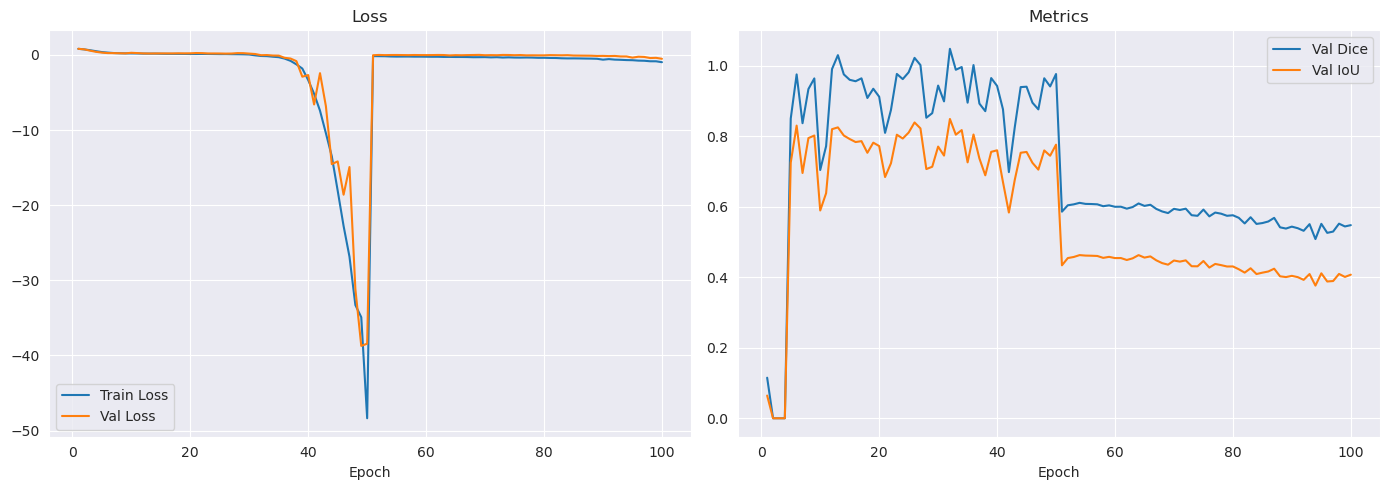

In [ ]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['val_dice'], label='Val Dice')
axes[1].plot(epochs, history['val_iou'],  label='Val IoU')
axes[1].set_title('Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

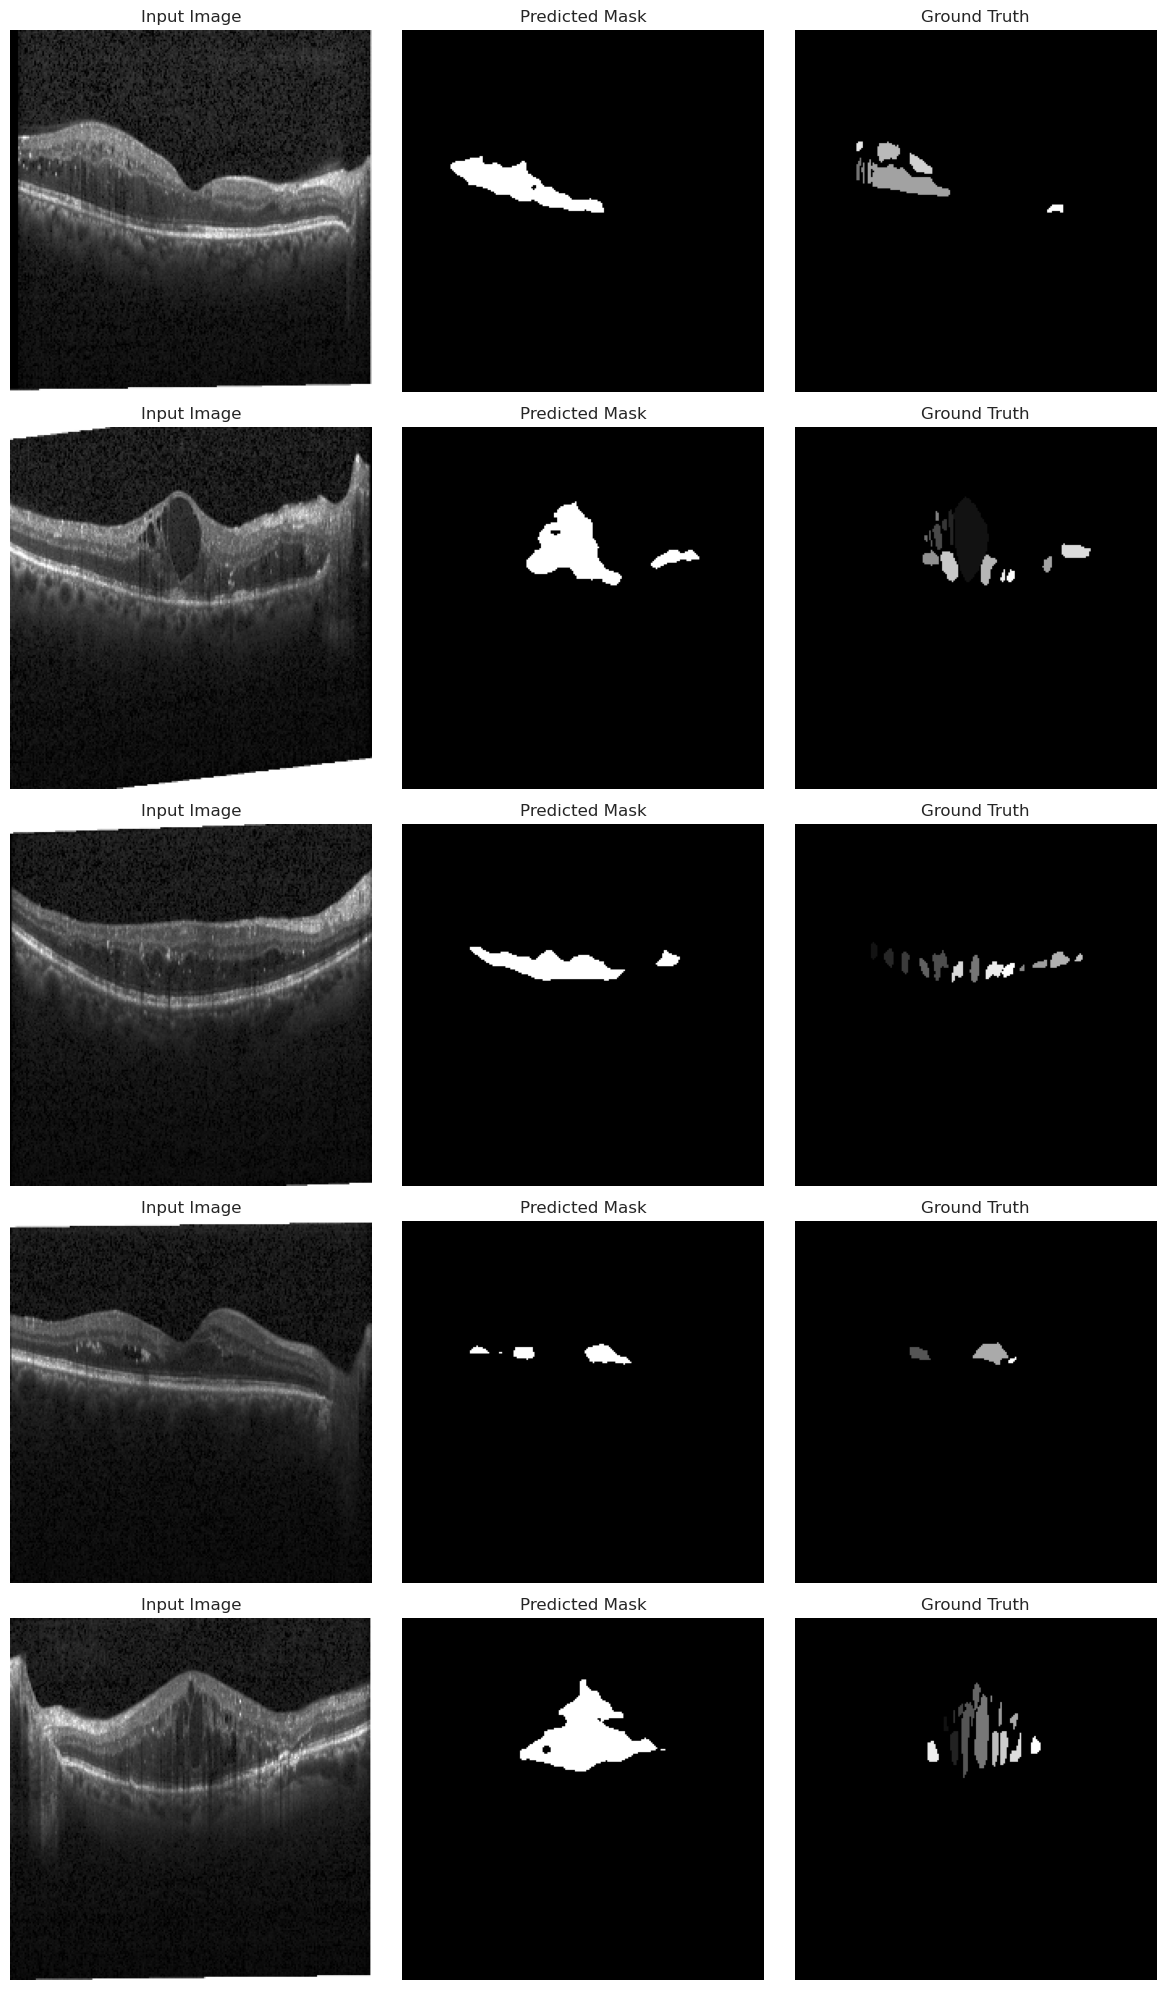

In [ ]:
def plot_examples(loader, num_examples: int = 5):
    model.eval()
    fig, axes = plt.subplots(num_examples, 3, figsize=(12, num_examples * 4))
    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = (torch.sigmoid(model(images)) > 0.5)
            for b in range(images.shape[0]):
                if shown >= num_examples:
                    break
                img_np  = images[b].cpu().permute(1, 2, 0).numpy()
                # Normalise to [0,1] for display
                img_np  = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
                axes[shown][0].imshow(img_np)
                axes[shown][0].set_title('Input Image')
                axes[shown][1].imshow(preds[b, 0].cpu(), cmap='gray')
                axes[shown][1].set_title('Predicted Mask')
                axes[shown][2].imshow(masks[b, 0].cpu(), cmap='gray')
                axes[shown][2].set_title('Ground Truth')
                for ax in axes[shown]:
                    ax.axis('off')
                shown += 1
            if shown >= num_examples:
                break
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150)
    plt.show()

plot_examples(test_loader, num_examples=5)